In [5]:
from src.preprocessing.io.feature_loader import FeatureLoader
from src.common.constants import Constants as consts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Visualizations For WavLM

## UMAP

In [3]:
feature_loader = FeatureLoader(feat_suffix=consts.wavlm_emb_suffix)
all_meta, all_feats = feature_loader.load_data()
print(all_feats.shape, all_meta.shape)

meta, feats = feature_loader.sample_data(metadata=all_meta, features=all_feats, fraction=0.2)
print(feats.shape, meta.shape)

2026-05-24 00:40:15 | INFO     | FeatureLoader | Using WavLM embeddings suffix
2026-05-24 00:40:15 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_wavlm.npy
2026-05-24 00:40:15 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-24 00:40:15 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-24 00:40:15 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(1125881, 768) (1125881, 9)
(225176, 768) (225176, 9)


In [7]:
X_umap_2d_wavlm = np.load(consts.results_dir / "X_umap_2d_more_details.npy")
print(X_umap_2d_wavlm.shape)

no_anomalies_mask = meta["anomaly"] == 0
X_umap_2d_wavlm_no_anomalies = X_umap_2d_wavlm[no_anomalies_mask]
meta_no_anomalies = meta[no_anomalies_mask]
print(X_umap_2d_wavlm_no_anomalies.shape, meta_no_anomalies.shape)

(225176, 2)
(208972, 2) (208972, 9)


In [62]:
def plot_umap_2d(X_umap_2d, plot_configs: list[dict], use_legend: bool = False, markerscale: float = 3, fontsize: float = 12):
    plt.figure(figsize=(10, 10))
    for config in plot_configs:
        mask = config.get("mask", np.ones(X_umap_2d.shape[0], dtype=bool))
        label = config.get("label", None)
        color = config["color"]
        alpha = config.get("alpha", 0.5)
        size = config.get("size", 0.5)
        cmap = plt.get_cmap("tab20") if isinstance(color, pd.Series) else None

        plt.scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1], label=label, alpha=alpha, c=color, s=size, cmap=cmap)
    if use_legend:
        plt.legend(markerscale=markerscale, fontsize=fontsize)
    plt.xticks([])
    plt.yticks([])
    plt.show()

#

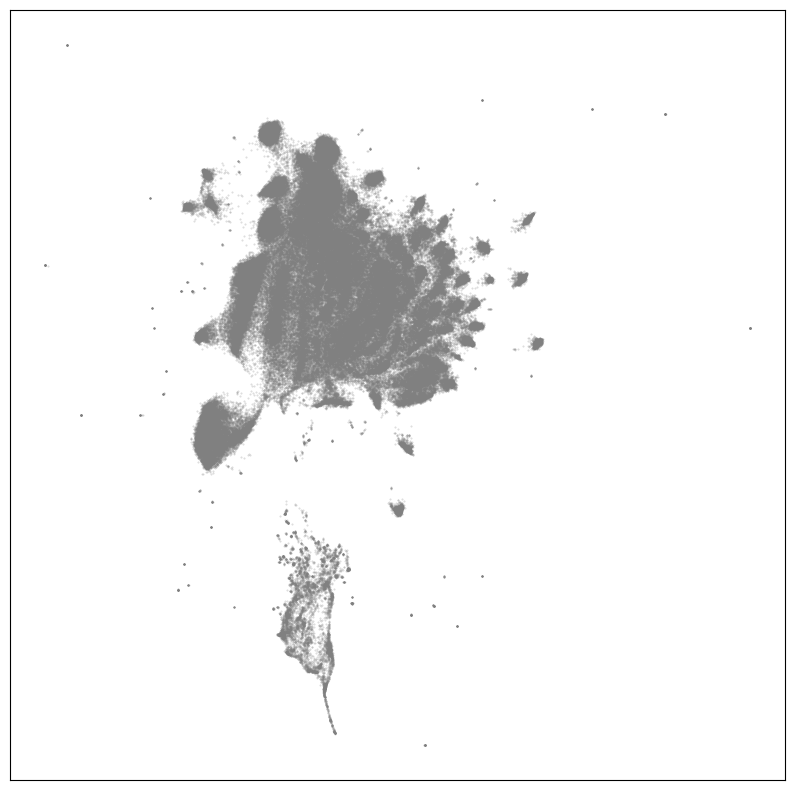

In [24]:
plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.3}
]

plot_umap_2d(X_umap_2d_wavlm, plot_configs)

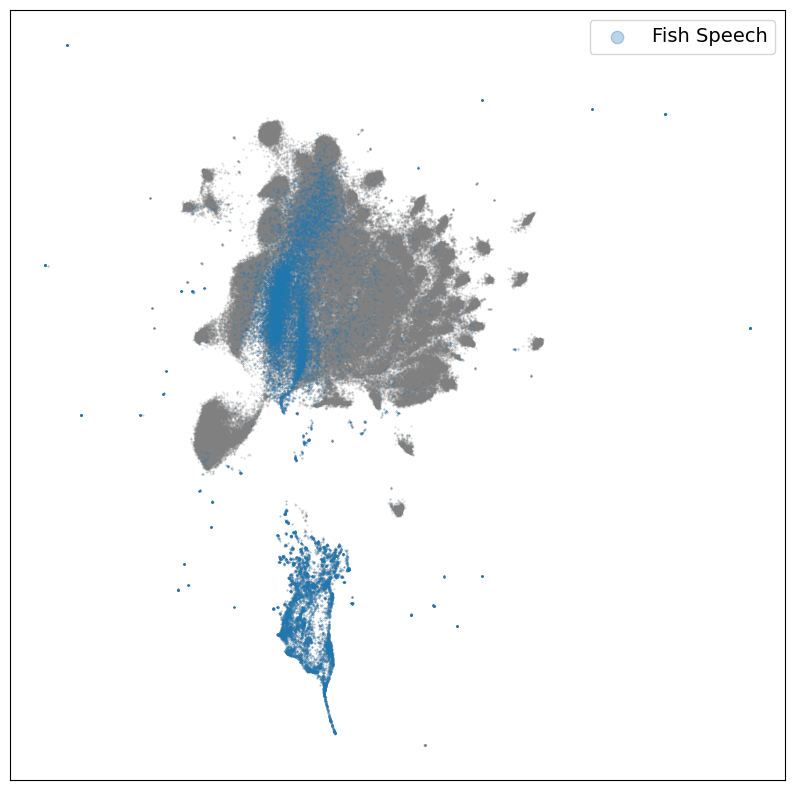

In [41]:
fish_speech = meta['config'].str.contains("fish_speech")

plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.3},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.3, "mask": fish_speech, "label": "Fish Speech", "use_legend": True},
]

plot_umap_2d(X_umap_2d_wavlm, plot_configs, use_legend=True, markerscale=20, fontsize=14)

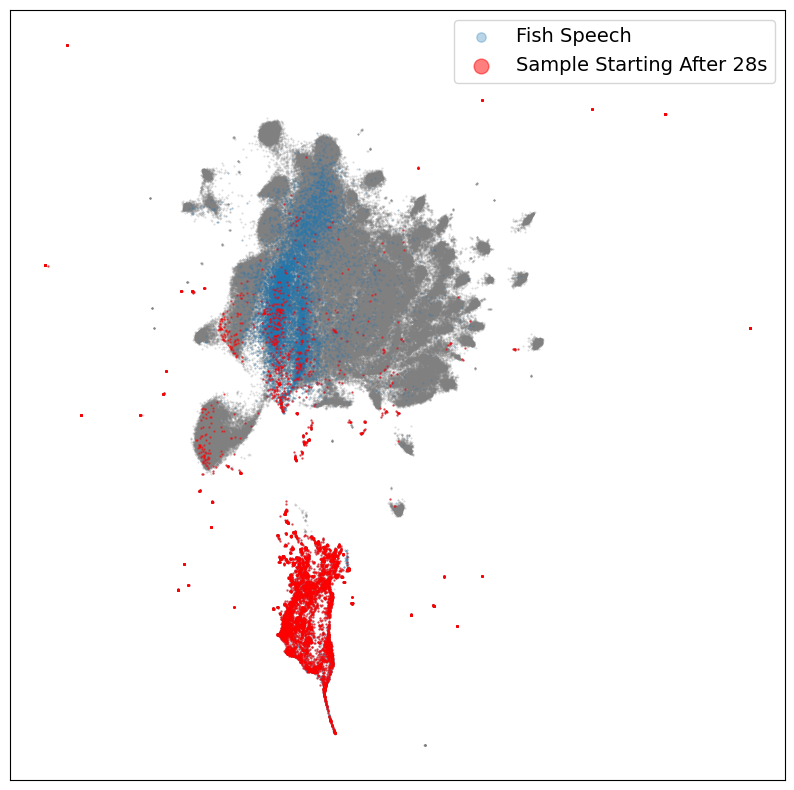

In [51]:
starting_after_28s = meta['starting_point'] >= 28
plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.3},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.3, "mask": fish_speech, "label": "Fish Speech"},
    {"color": "red", "size": 0.5, "alpha": 0.5, "mask": starting_after_28s, "label": "Sample Starting After 28s"}
]

plot_umap_2d(X_umap_2d_wavlm, plot_configs, use_legend=True, markerscale=15, fontsize=14)

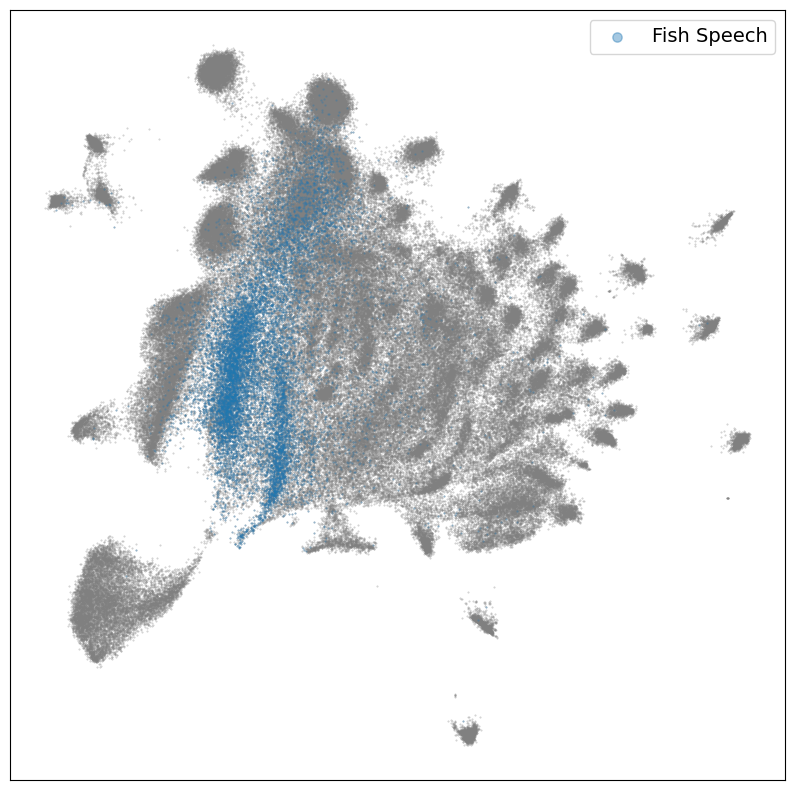

In [52]:
plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.4},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.4, "mask": fish_speech[no_anomalies_mask], "label": "Fish Speech"},
    # {"color": "red", "size": 0.5, "alpha": 0.5, "mask": starting_after_28s, "label": "Starting After 28s"}
]

plot_umap_2d(X_umap_2d_wavlm_no_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

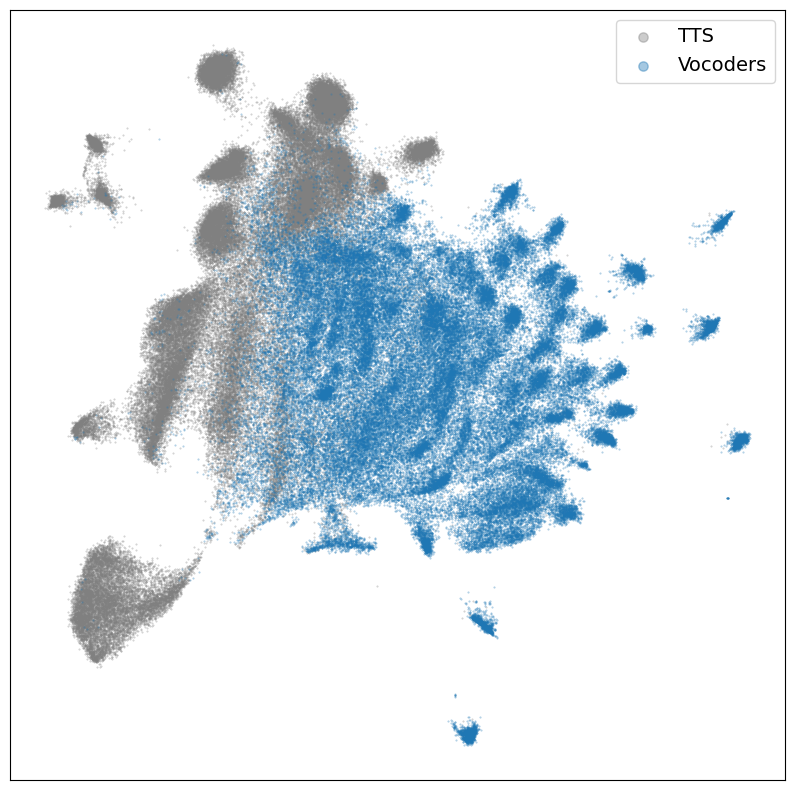

In [59]:
bonafide_mask = meta_no_anomalies["target"] == 'bonafide'
vocoders_mask = meta_no_anomalies["config"].str.contains("vocoders")
tts_mask = meta_no_anomalies["config"].str.contains("tts")

plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.4, "mask": tts_mask, "label": "TTS"},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.4, "mask": vocoders_mask, "label": "Vocoders"},
]

plot_umap_2d(X_umap_2d_wavlm_no_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

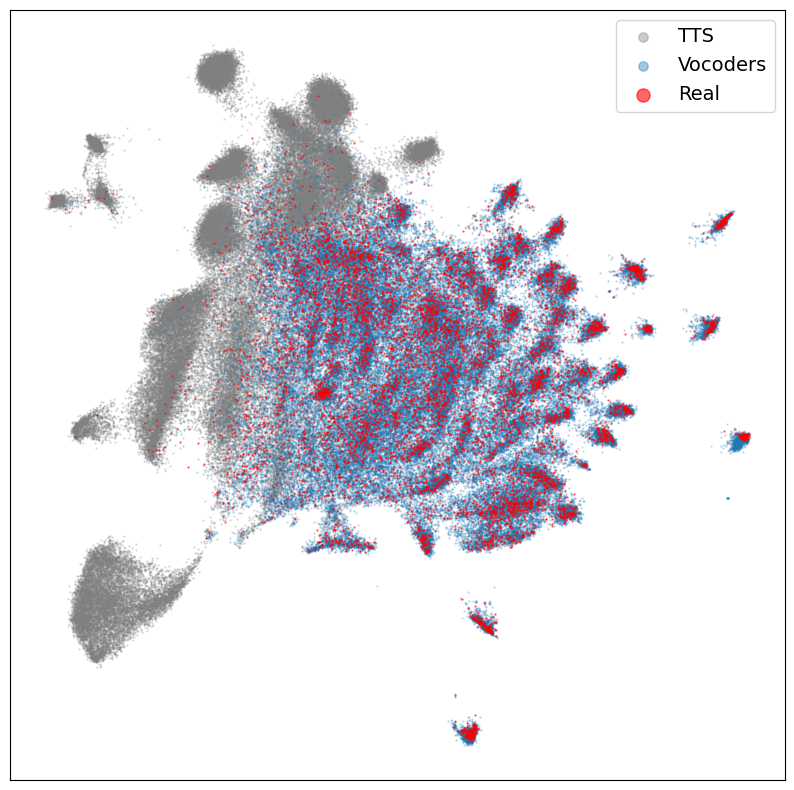

In [ ]:
bonafide_mask = meta_no_anomalies["target"] == 'bonafide'
vocoders_mask = meta_no_anomalies["config"].str.contains("vocoders")
tts_mask = meta_no_anomalies["config"].str.contains("tts")

plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.4, "mask": tts_mask, "label": "TTS"},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.4, "mask": vocoders_mask, "label": "Vocoders"},
    {"color": "red", "size": 0.4, "alpha": 0.6, "mask": bonafide_mask, "label": "Real"},
]

plot_umap_2d(X_umap_2d_wavlm_no_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

In [60]:
uq_map = {
    "mls-tts-chattts": 0,
    "mls-vocoders-bigvgan": 1,
    "mls-tts-xtts": 2,
    "mls-vocoders-hifigan": 3,
    "mls-tts-f5_tts": 4,
    "mls-tts-sparktts": 5,
    "mls-tts-zonos": 6,
    "mls-vocoders-parallel_wavegan": 7,
    "mls-vocoders-melgan": 8,
    "mls-vocoders-style_melgan": 9,
    "mls-vocoders-full_band_melgan": 10,
    "mls-vocoders-vocos": 11,
    "mls-vocoders-bigvsan": 12,
    "mls-vocoders-univnet": 13,
    "mls-vocoders-multi_band_melgan": 14,
    "mls-bonafide": 15,
    "mls-tts-yourtts": 16,
    "mls-tts-bark": 17,
    "mls-tts-fish_speech": 18,
    "mls-tts-cosyvoice": 19,
    "mls-tts-vits": 20,
}

cluster_ids = meta_no_anomalies["config"].map(uq_map)

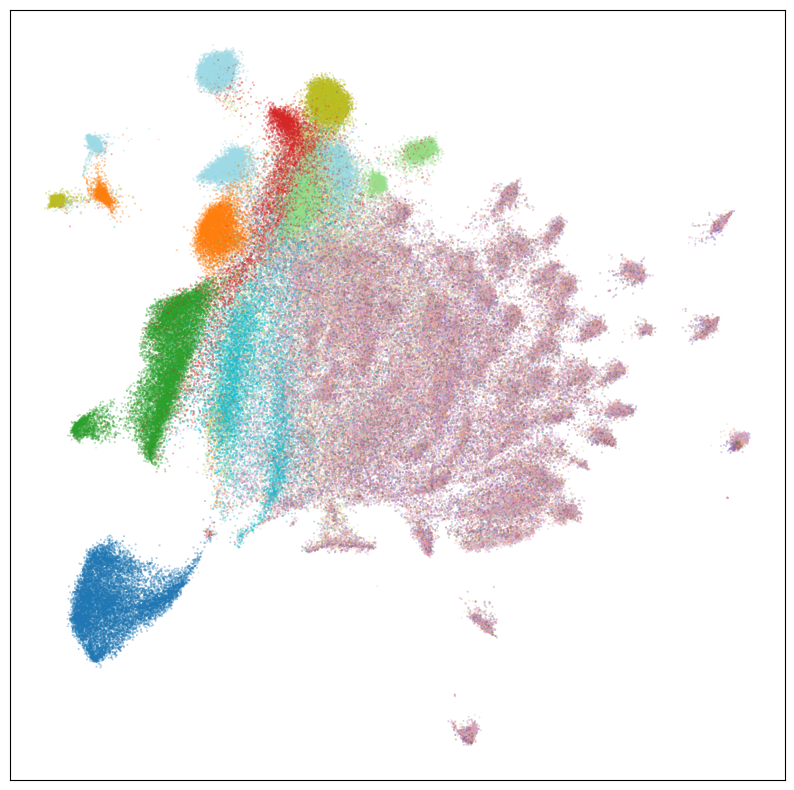

In [63]:
plot_configs = [
    {"color": cluster_ids, "size": 0.2, "alpha": 0.4, "label": "TTS"},
]

plot_umap_2d(X_umap_2d_wavlm_no_anomalies, plot_configs, use_legend=False, markerscale=15, fontsize=14)

## tSNE

In [68]:
X_tsne_wavlm_no_anomalies = np.load(consts.results_dir / "tsne_no_anomalies_20p.npy")
print(X_tsne_wavlm_no_anomalies.shape)

(208972, 2)


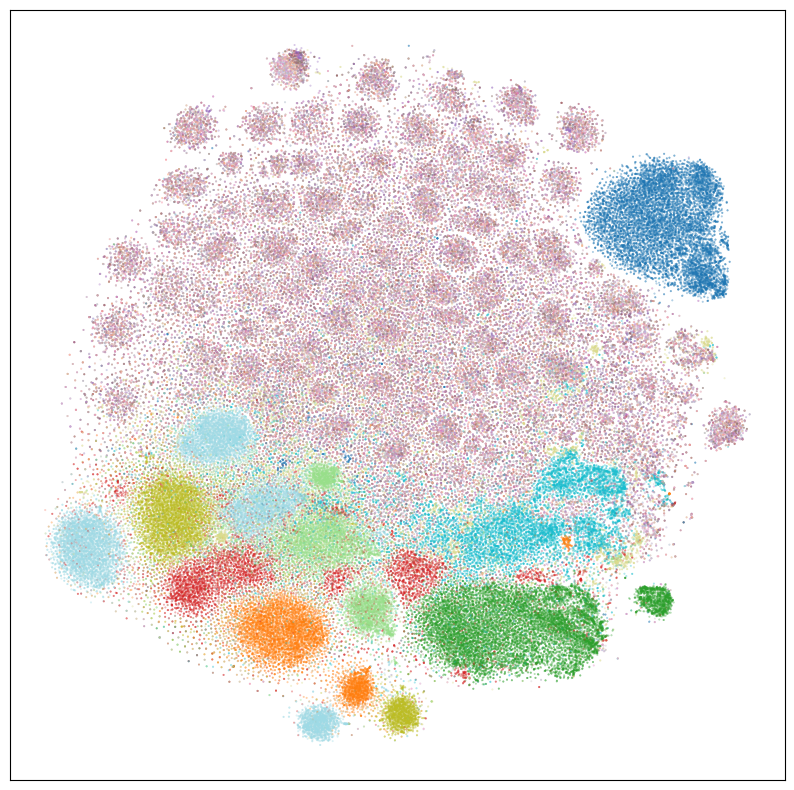

In [69]:
plot_configs = [
    {"color": cluster_ids, "size": 0.2, "alpha": 0.4, "label": "TTS"},
]

plot_umap_2d(X_tsne_wavlm_no_anomalies, plot_configs, use_legend=False, markerscale=15, fontsize=14)

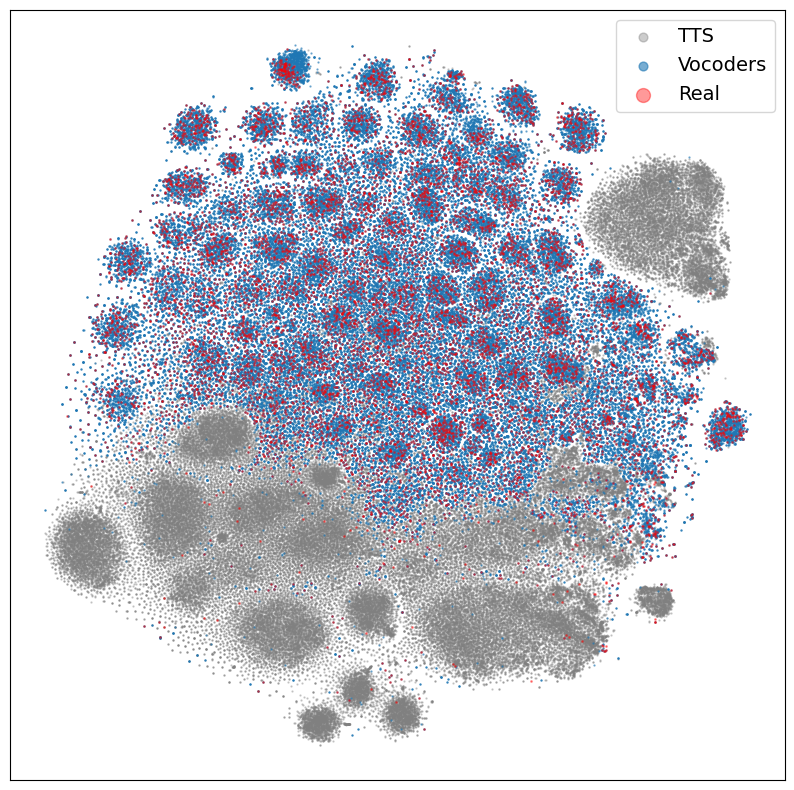

In [82]:
bonafide_mask = meta_no_anomalies["target"] == 'bonafide'
vocoders_mask = meta_no_anomalies["config"].str.contains("vocoders")
tts_mask = meta_no_anomalies["config"].str.contains("tts")

plot_configs = [
    {"color": "grey", "size": 0.4, "alpha": 0.4, "mask": tts_mask, "label": "TTS"},
    {"color": "tab:blue", "size": 0.4, "alpha": 0.6, "mask": vocoders_mask, "label": "Vocoders"},
    {"color": "red", "size": 1.0, "alpha": 0.4, "mask": bonafide_mask, "label": "Real"},
]

plot_umap_2d(X_tsne_wavlm_no_anomalies, plot_configs, use_legend=True, markerscale=10, fontsize=14)

In [84]:
X_tsne_wavlm_with_anomalies = np.load(consts.results_dir / "tsne_all_feats_20p.npy")
print(X_tsne_wavlm_with_anomalies.shape)

(225176, 2)


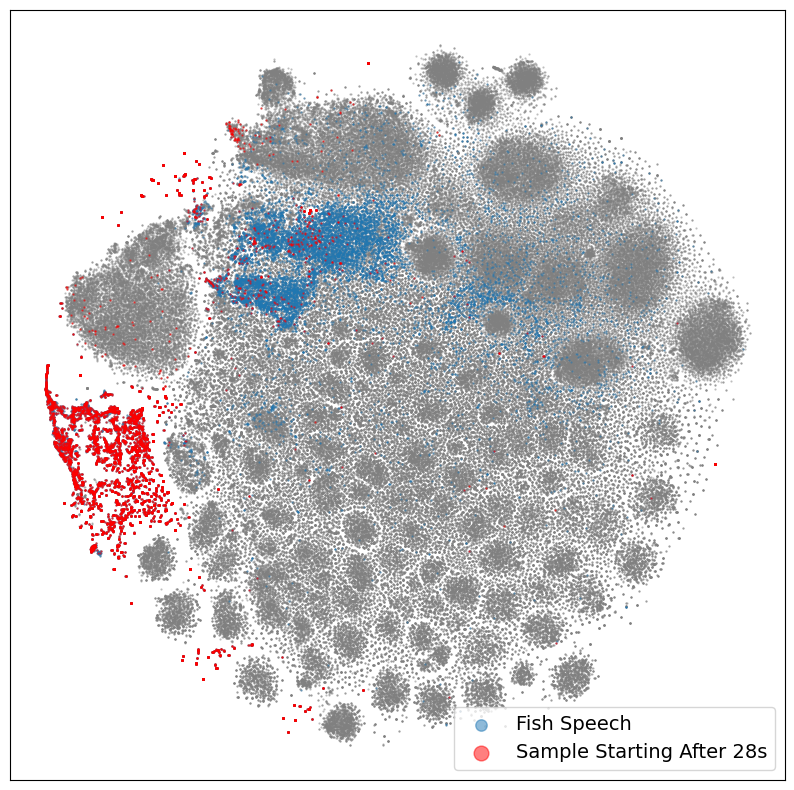

In [88]:
starting_after_28s = meta['starting_point'] >= 28
plot_configs = [
    {"color": "grey", "size": 0.3, "alpha": 0.5},
    {"color": "tab:blue", "size": 0.3, "alpha": 0.5, "mask": fish_speech, "label": "Fish Speech"},
    {"color": "red", "size": 0.5, "alpha": 0.5, "mask": starting_after_28s, "label": "Sample Starting After 28s"}
]

plot_umap_2d(X_tsne_wavlm_with_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

# Visualizations For FFT

In [107]:
feature_loader = FeatureLoader(feat_suffix=consts.fft_emb_suffix)

all_meta_fft, all_feats_fft = feature_loader.load_data()
print(all_feats_fft.shape, all_meta_fft.shape)

meta_fft, feats_fft = feature_loader.sample_data(metadata=all_meta_fft, features=all_feats_fft, fraction=0.1)
print(feats_fft.shape, meta_fft.shape)

del all_meta_fft, all_feats_fft

2026-05-24 01:51:28 | INFO     | FeatureLoader | Using FFT embeddings suffix
2026-05-24 01:51:28 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted_fft.npy
2026-05-24 01:51:28 | INFO     | FeatureLoader | Constructed file path: /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-24 01:51:28 | INFO     | FeatureLoader | Loading features from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv
2026-05-24 01:51:28 | INFO     | FeatureLoader | Loading metadata from /Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/data/collected_data/feature_extracted.csv


(1125881, 1026) (1125881, 9)
(112588, 1026) (112588, 9)


In [99]:
from sklearn.preprocessing import Normalizer
from umap import UMAP

norm_feats = Normalizer("l2").fit_transform(feats_fft)

umap_model = UMAP(
    n_components=2,
    n_neighbors=120,  # większe = gładsza struktura
    min_dist=0.6,  # większe = bardziej rozproszone klastry
    metric="euclidean",
    random_state=42,
)

X_umap_2d_fft = umap_model.fit_transform(norm_feats)

/Users/mikolajkarapka/Projects/audio-deepfake-detection-uwr/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [104]:
X_umap_2d_no_anomalies_fft = X_umap_2d_fft[no_anomalies_mask]

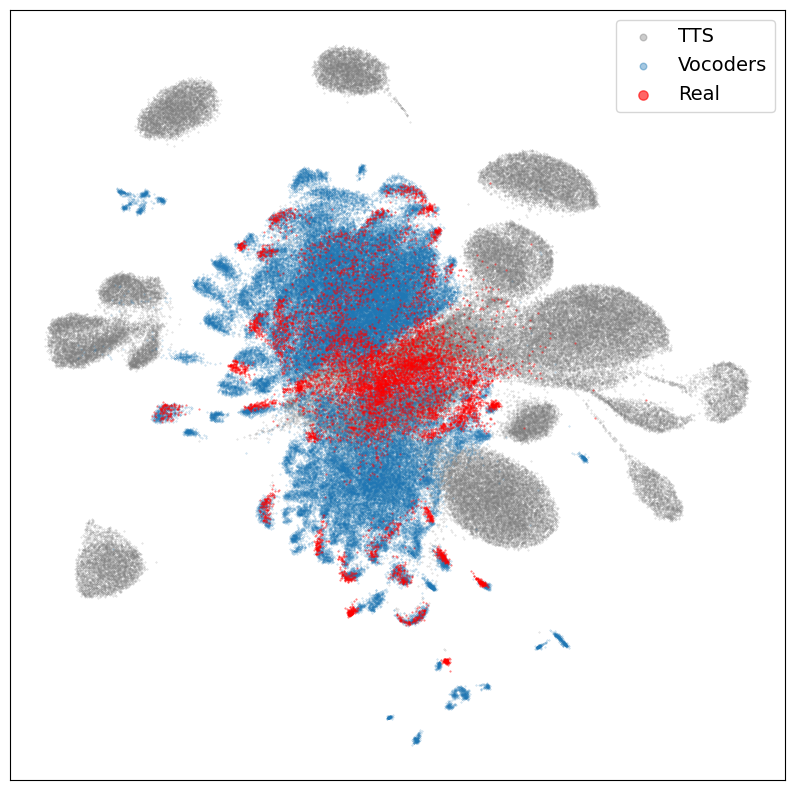

In [106]:
bonafide_mask = meta_no_anomalies["target"] == 'bonafide'
vocoders_mask = meta_no_anomalies["config"].str.contains("vocoders")
tts_mask = meta_no_anomalies["config"].str.contains("tts")

plot_configs = [
    {"color": "grey", "size": 0.1, "alpha": 0.4, "mask": tts_mask, "label": "TTS"},
    {"color": "tab:blue", "size": 0.1, "alpha": 0.4, "mask": vocoders_mask, "label": "Vocoders"},
    {"color": "red", "size": 0.2, "alpha": 0.6, "mask": bonafide_mask, "label": "Real"},
]

plot_umap_2d(X_umap_2d_no_anomalies_fft, plot_configs, use_legend=True, markerscale=15, fontsize=14)

In [108]:
X_umap_2d_fft_no_anomalies = np.load(consts.results_dir / "umap_2d_fft.npy")
print(X_umap_2d_fft_no_anomalies.shape)

no_anomalies_mask = meta_fft["anomaly"] == 0
meta_fft_no_anomalies = meta_fft[no_anomalies_mask]
print(X_umap_2d_fft_no_anomalies.shape, meta_fft_no_anomalies.shape)

(104540, 2)
(104540, 2) (104540, 9)


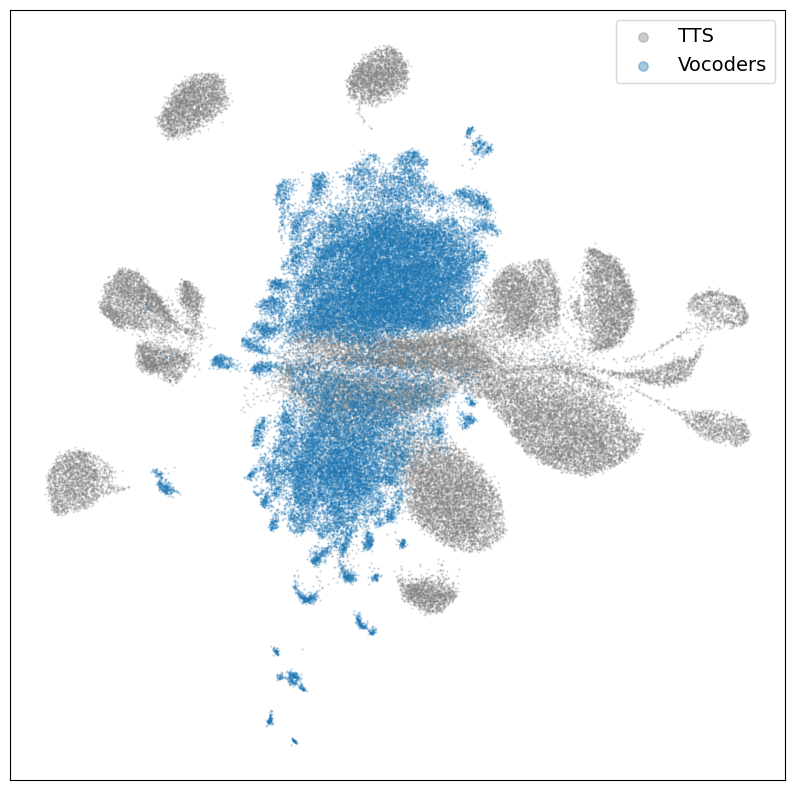

In [109]:
bonafide_mask_fft = meta_fft_no_anomalies["target"] == 'bonafide'
vocoders_mask_fft = meta_fft_no_anomalies["config"].str.contains("vocoders")
tts_mask_fft = meta_fft_no_anomalies["config"].str.contains("tts")

plot_configs = [
    {"color": "grey", "size": 0.2, "alpha": 0.4, "mask": tts_mask_fft, "label": "TTS"},
    {"color": "tab:blue", "size": 0.2, "alpha": 0.4, "mask": vocoders_mask_fft, "label": "Vocoders"},
]

plot_umap_2d(X_umap_2d_fft_no_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

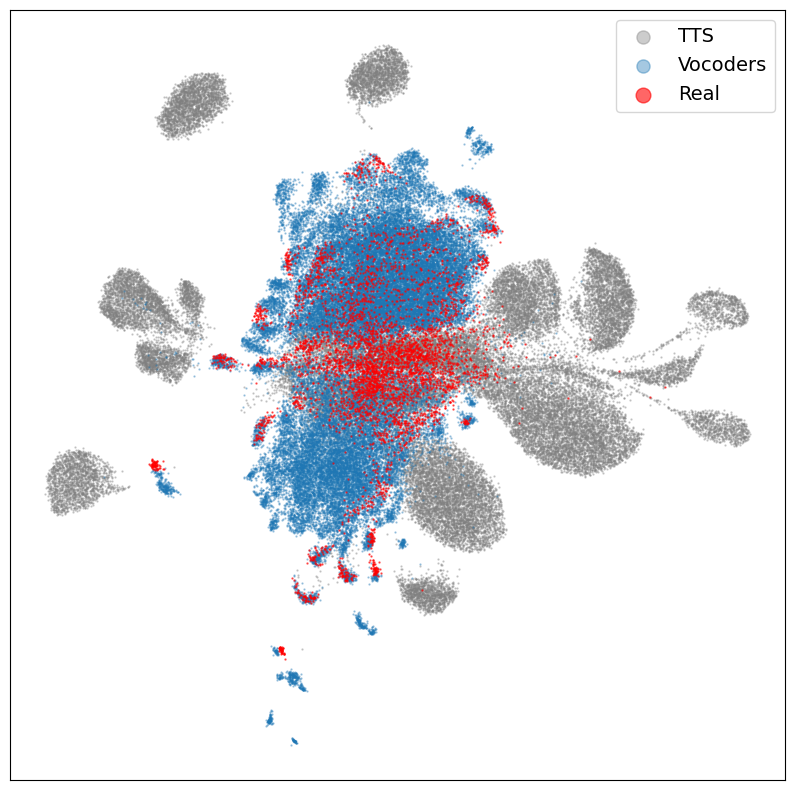

In [117]:
plot_configs = [
    {"color": "grey", "size": 0.4, "alpha": 0.4, "mask": tts_mask_fft, "label": "TTS"},
    {"color": "tab:blue", "size": 0.4, "alpha": 0.4, "mask": vocoders_mask_fft, "label": "Vocoders"},
    {"color": "red", "size": 0.5, "alpha": 0.6, "mask": bonafide_mask_fft, "label": "Real"},
]

plot_umap_2d(X_umap_2d_fft_no_anomalies, plot_configs, use_legend=True, markerscale=15, fontsize=14)

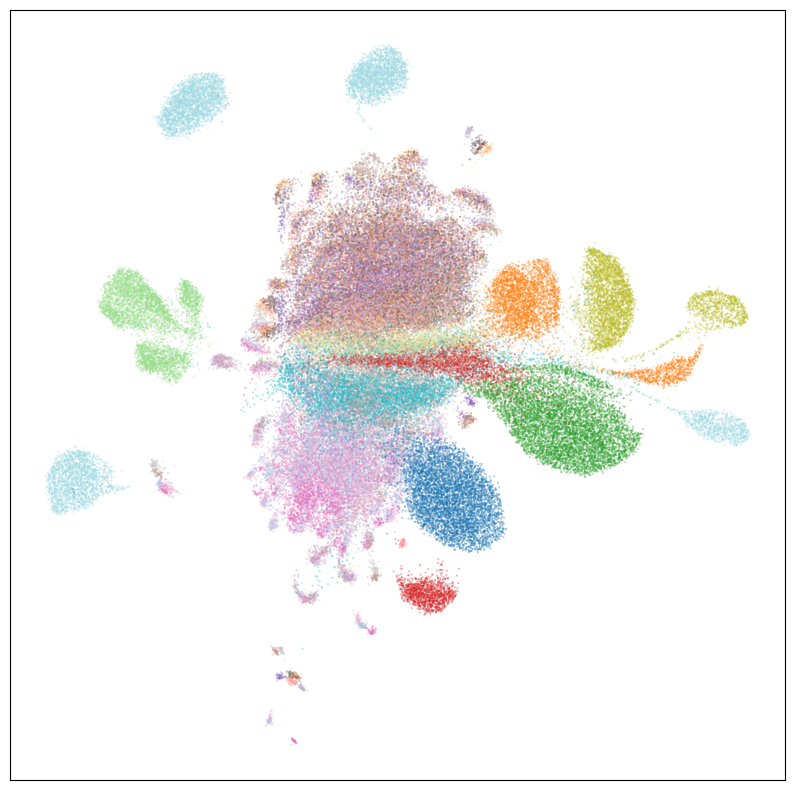

In [119]:
cluster_ids_fft = meta_fft_no_anomalies["config"].map(uq_map)
plot_configs = [
    {"color": cluster_ids_fft, "size": 0.2, "alpha": 0.4, "label": "TTS"},
]

plot_umap_2d(X_umap_2d_fft_no_anomalies, plot_configs, use_legend=False, markerscale=15, fontsize=14)

In [121]:
tsne_fft = np.load(consts.results_dir / "tsne_2_fft.npy")
print(tsne_fft.shape)

(208972, 2)


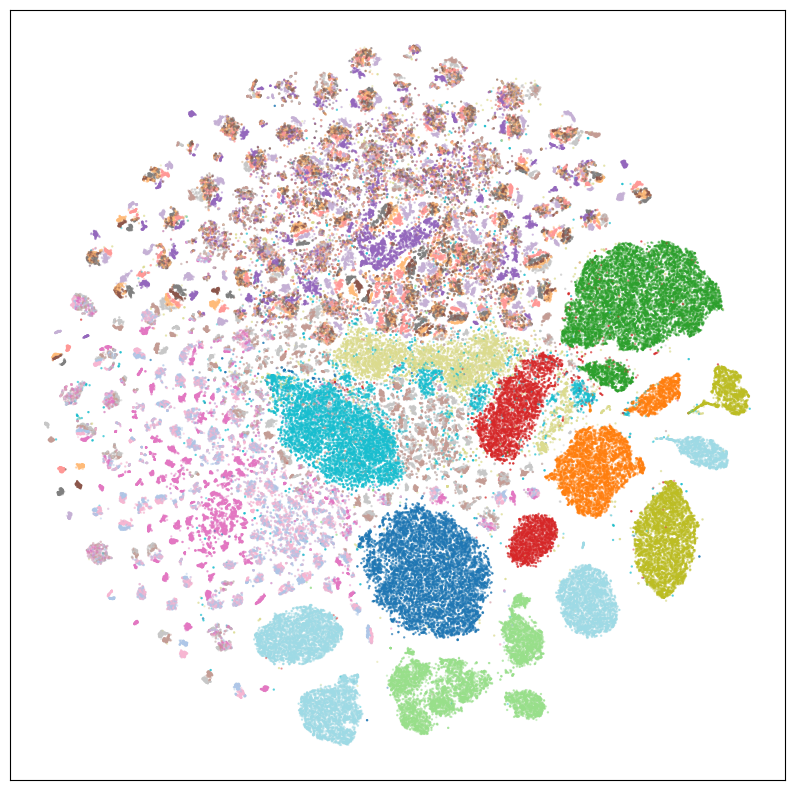

In [128]:
plot_configs = [
    {"color": cluster_ids, "size": 0.4, "alpha": 0.4, "label": "TTS"},
]

plot_umap_2d(tsne_fft, plot_configs, use_legend=False, markerscale=15, fontsize=14)

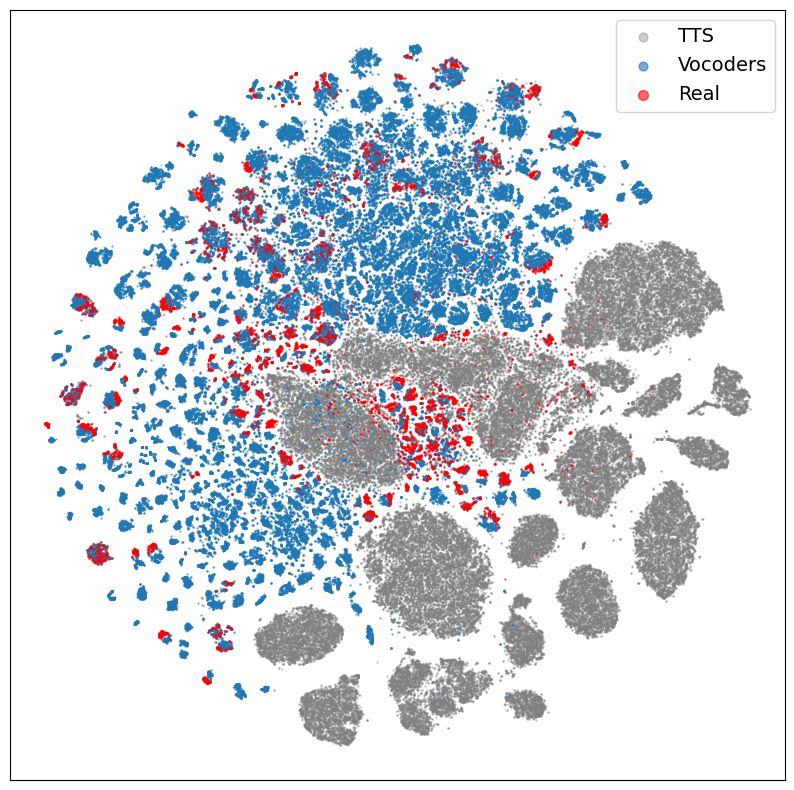

In [126]:
plot_configs = [
    {"color": "grey", "size": 0.4, "alpha": 0.4, "mask": tts_mask, "label": "TTS"},
    {"color": "tab:blue", "size": 0.4, "alpha": 0.6, "mask": vocoders_mask, "label": "Vocoders"},
    {"color": "red", "size": 0.5, "alpha": 0.6, "mask": bonafide_mask, "label": "Real"},
]

plot_umap_2d(tsne_fft, plot_configs, use_legend=True, markerscale=10, fontsize=14)